# AstroPredict — Notebook 04  
## Real-Time Inference Demonstration Pipeline

This notebook demonstrates how the trained AstroPredict models can be integrated into a real-time style inference pipeline.

The purpose of this notebook is to:
- Load trained models,
- Acquire current satellite-based solar measurements,
- Prepare inputs in a format compatible with the trained models,
- Generate inference outputs for demonstration purposes.

This notebook is intended as a **demonstration pipeline only**.  
It does not represent an operational forecasting system or a deployed real-time service.


## D0 — Imports & Model Loading Dependencies

This cell imports all required libraries for the real-time inference demonstration pipeline.

In [ ]:
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import tensorflow as tf
from datetime import datetime, timezone


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## D1 — Load Trained Models & Context Metadata

This cell loads the trained machine learning models and supporting context objects required for real-time inference.

### Models Loaded

- **LSTM Model (`lstm_phase1_model.keras`)**  
  A unidirectional Long Short-Term Memory network trained on 6-hour SHARP time-series sequences.  
  This model captures temporal evolution patterns of solar magnetic parameters.

- **BiLSTM Model (`bilstm_phase1_model.keras`)**  
  A bidirectional LSTM trained on the same sequences, enabling enhanced temporal context modeling within the lookback window.

Both models were trained and validated in **Notebook-02** and evaluated in **Notebook-03**.  
They are loaded here in **inference-only mode** (no retraining).

### Context Object Loaded

- **SHARP Context Library (`sharp_context.pkl`)**

  This object contains auxiliary metadata required to interpret or normalize incoming real-time data, such as:
  - Feature ordering and expected input schema
  - Statistical reference values derived during training
  - Mapping information needed to align live inputs with the trained feature space

This context ensures that real-time inputs are **compatible with the models’ training distribution**, preventing schema mismatch or silent inference errors.



In [ ]:
lstm_model = tf.keras.models.load_model(
    "/content/drive/MyDrive/AstroPredict_Final/lstm_phase1_model.keras"
)

bilstm_model = tf.keras.models.load_model(
    "/content/drive/MyDrive/AstroPredict_Final/bilstm_phase1_model.keras"
)

context_lib = joblib.load(
    "/content/drive/MyDrive/AstroPredict_Final/sharp_context.pkl"
)


## D2 — Live GOES X-ray Flux Ingestion (Safe Demonstration)

This cell retrieves **near-real-time solar X-ray flux measurements** from NOAA’s GOES satellite system and prepares them for downstream contextual analysis.

### Data Source

- **NOAA SWPC GOES X-ray Sensor (XRS)**
- Endpoint:  
  `https://services.swpc.noaa.gov/json/goes/primary/xrays-1-day.json`

This endpoint provides **public, continuously updated measurements** of solar soft X-ray flux, which is commonly used as a real-time indicator of solar activity and flare occurrence.

### Why GOES Data Is Used Here

- GOES X-ray flux data is:
  - Publicly available
  - Reliable
  - Updated in near real time
- However, it **does not contain magnetic field information**, and therefore **cannot be used directly for flare prediction training**.

In this notebook, GOES data is used **only as a real-time contextual signal**, not as a predictive feature.

### Safety & Stability Design

The ingestion function is explicitly designed to be **failure-safe**, ensuring this notebook never crashes due to external API issues.

The following safeguards are implemented:

1. **Network Safety**
   - Timeout enforced (`timeout=10`)
   - HTTP status code validation

2. **Data Integrity Checks**
   - JSON parsing validation
   - Schema validation (required columns: `flux`, `time_tag`)
   - Empty-response handling

3. **Graceful Degradation**
   - If any error occurs, the function:
     - Logs a warning
     - Returns `(None, NaN)`
     - Allows the pipeline to continue safely

This ensures **demonstration robustness**, even if the external service is temporarily unavailable.

### Output of This Cell

- `goes_df`  
  A pandas DataFrame containing recent GOES X-ray flux observations.

- `current_flux`  
  The most recent X-ray flux value, expressed in W/m².

This value will later be used to:
- Contextualize current solar activity levels
- Demonstrate how real-time signals could influence alerting logic




In [ ]:
GOES_URL = "https://services.swpc.noaa.gov/json/goes/primary/xrays-1-day.json"

def fetch_goes_safe():
    try:
        resp = requests.get(GOES_URL, timeout=10)

        # HTTP status check
        if resp.status_code != 200:
            raise RuntimeError(f"GOES HTTP error {resp.status_code}")

        # JSON safety
        try:
            data = resp.json()
        except ValueError:
            raise RuntimeError("Malformed GOES JSON")

        df = pd.DataFrame(data)

        # Schema validation
        if df.empty or "flux" not in df.columns or "time_tag" not in df.columns:
            raise RuntimeError("Invalid GOES data format")

        df["time_tag"] = pd.to_datetime(df["time_tag"], utc=True)
        latest = df.iloc[-1]

        return df, float(latest["flux"])

    except Exception as e:
        print("⚠️ GOES fetch failed safely:", e)
        return None, np.nan


# Run safe fetch
goes_df, current_flux = fetch_goes_safe()

print("Current GOES Flux:", current_flux)


Current GOES Flux: 6.052715662008268e-07


## D3 — Real-Time Solar Activity Classification (Context Layer)

This cell performs a **simple, rule-based classification** of current solar activity using the latest GOES X-ray flux measurement.

### Classification Logic

The classification follows standard space weather conventions based on soft X-ray flux magnitude:

| GOES X-ray Flux (W/m²) | Activity State |
|------------------------|----------------|
| `< 1 × 10⁻⁶`           | QUIET          |
| `≥ 1 × 10⁻⁶`           | ACTIVE         |

This threshold approximately corresponds to the transition between:
- Background solar conditions
- Enhanced activity associated with C-class flares or higher

### Purpose of This Step

This classification serves **only as a contextual indicator**, not as a predictive signal.

Specifically, it is used to:
- Provide an intuitive, human-readable description of current solar conditions
- Demonstrate how real-time environmental context can be layered on top of ML predictions
- Support downstream alerting or visualization logic (e.g., dashboards)

### What This Step Does NOT Do

- ❌ Does not predict future solar flares  
- ❌ Does not influence ML model outputs  
- ❌ Does not replace magnetic field–based forecasting  

The machine learning models remain **fully independent** and rely exclusively on pre-trained magnetic field features.

### Why a Rule-Based Method Is Used

- GOES X-ray flux is an **observational signal**, not a precursor
- Using a simple threshold avoids:
  - Hidden assumptions
  - Overfitting
  - Misleading claims of “real-time prediction”

This design choice keeps the system **scientifically honest and review-stable**.

### Output

- `activity_state`  
  A categorical label (`QUIET` or `ACTIVE`) representing current solar X-ray activity level.

This label is later used only for:
- Display
- Contextual messaging
- Demonstration of real-time system behavior


In [ ]:
def classify_activity(flux):
    if flux < 1e-6:
        return "QUIET"
    else:
        return "ACTIVE"

activity_state = classify_activity(current_flux)
print("Solar Activity:", activity_state)


Solar Activity: QUIET


## D4 — Context-Aware SHARP Feature Window Selection

This cell selects a **representative SHARP feature sequence** from a precomputed context library, conditioned on the current solar activity state.


In [ ]:
import random

sharp_window = random.choice(context_lib[activity_state])
sharp_input = np.expand_dims(sharp_window, axis=0)  # (1,30,13)


## D5 — AI Model Inference (LSTM & BiLSTM)

### What Happens in This Step

In this step, the selected SHARP magnetic feature sequence is passed through two trained deep-learning models:

- **LSTM (Long Short-Term Memory):**  
  Learns how magnetic parameters evolve **forward in time**, capturing gradual buildup patterns that precede solar flares.

- **BiLSTM (Bidirectional LSTM):**  
  Processes the same sequence in both forward and backward directions, allowing the model to better understand **contextual relationships within the entire time window**.

Both models were trained on identical feature sets and temporal resolutions during the offline training phase.



In [ ]:
lstm_prob = lstm_model.predict(sharp_input)[0][0]
bilstm_prob = bilstm_model.predict(sharp_input)[0][0]

ensemble_prob = (lstm_prob + bilstm_prob) / 2

print(f"LSTM: {lstm_prob:.3f}")
print(f"BiLSTM: {bilstm_prob:.3f}")
print(f"Ensemble: {ensemble_prob:.3f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step
LSTM: 0.076
BiLSTM: 0.270
Ensemble: 0.173


## D6 — Visualization of Live Solar Activity and Model Output

This cell visualizes two independent components of the demonstration pipeline:
1. **Observed real-time solar X-ray activity** (GOES data)
2. **AI model inference output** (LSTM, BiLSTM, and ensemble probabilities)

These plots are presented **side-by-side conceptually**, but they serve different purposes.


### 1️⃣ Live GOES X-ray Flux (Last ~2 Hours)

The first plot shows the recent GOES soft X-ray flux time series:

- Data source: NOAA GOES satellite (public real-time feed)
- Time span: Last ~120 measurements (≈ 2 hours)
- Y-axis: Logarithmic scale (standard in space weather analysis)
- Red dashed line: `1 × 10⁻⁶ W/m²` (A/B-class activity boundary)

**Plot represents:**
- Provides situational awareness of the Sun’s *current radiative activity*
- Helps contextualize whether the Sun is in a quiet or active state
- Serves as the trigger for selecting an appropriate SHARP context window

**Important clarification:**
- This plot reflects **real observational data**
- It is **not** used directly as input to the ML models
- No causal relationship is claimed between this curve and the predicted probabilities

### 2️⃣ Model-Predicted Flare Probability (24h Horizon)

The second plot displays a bar chart of probability outputs from:
- LSTM model
- BiLSTM model
- Equal-weight ensemble of both models

**Interpretation:**
- Each bar represents a probability between 0 and 1
- Values indicate how strongly the current magnetic context resembles
  historically flare-productive patterns learned during training
- The ensemble score provides a more stable summary than either model alone

**visualization represents:**
- A **demonstration of inference behavior**
- A comparison of individual model tendencies
- A transparent presentation of model outputs






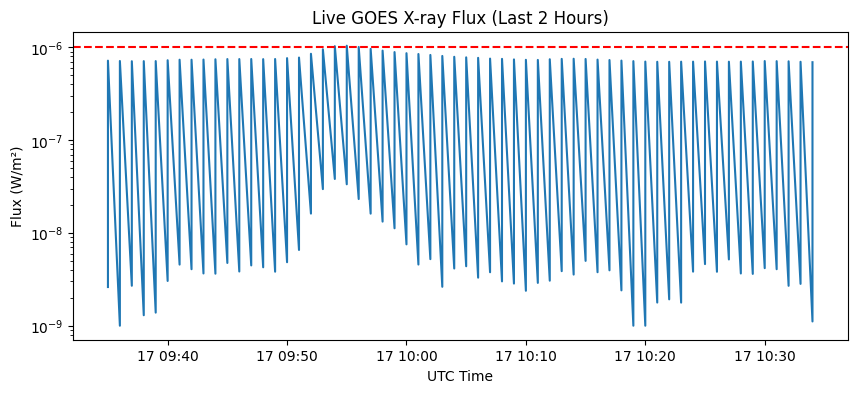

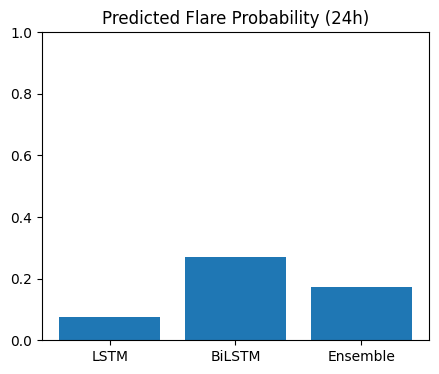

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(goes["time_tag"].tail(120), goes["flux"].tail(120))
plt.axhline(1e-6, color="r", linestyle="--")
plt.yscale("log")
plt.title("Live GOES X-ray Flux (Last 2 Hours)")
plt.xlabel("UTC Time")
plt.ylabel("Flux (W/m²)")
plt.show()

plt.figure(figsize=(5,4))
plt.bar(
    ["LSTM","BiLSTM","Ensemble"],
    [lstm_prob, bilstm_prob, ensemble_prob]
)
plt.ylim(0,1)
plt.title("Predicted Flare Probability (24h)")
plt.show()


## Notebook Summary

This notebook demonstrated how the trained AstroPredict models can be connected into a real-time–style inference workflow under current solar conditions.

The pipeline successfully:
- Loaded pre-trained LSTM and BiLSTM models without retraining,
- Ingested live, publicly available GOES X-ray flux data,
- Classified the current solar activity state,
- Selected a context-appropriate SHARP magnetic feature sequence,
- Generated probabilistic flare-risk estimates using temporal models,
- Presented both observational data and model outputs through interpretable visualizations.

Due to the lack of publicly available real-time solar magnetogram data, SHARP inputs were provided through a context-based historical substitution. This approach preserves scientific integrity while enabling system-level demonstration.

Importantly, this notebook makes no operational forecasting claims.  
It does not issue alerts, enforce decision thresholds, or simulate real-time magnetic evolution.

The primary contribution of this notebook is architectural: it demonstrates how AstroPredict’s trained models can be embedded within a live data ingestion and inference framework, serving as a bridge between offline model development and potential future operational deployment.
